Support Vector Machines: maximizing the margin between classes, and the kernel trick for non-linearly-separable data. Uses synthetic 2D data (for visualizing decision boundaries) plus the wine dataset for a real multi-class pipeline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

def plot_decision_boundary(model, X, y, ax, title):
    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
        np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300),
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=40)
    ax.set_title(title)

In [2]:
# Non-linearly separable data: two interleaving moons
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

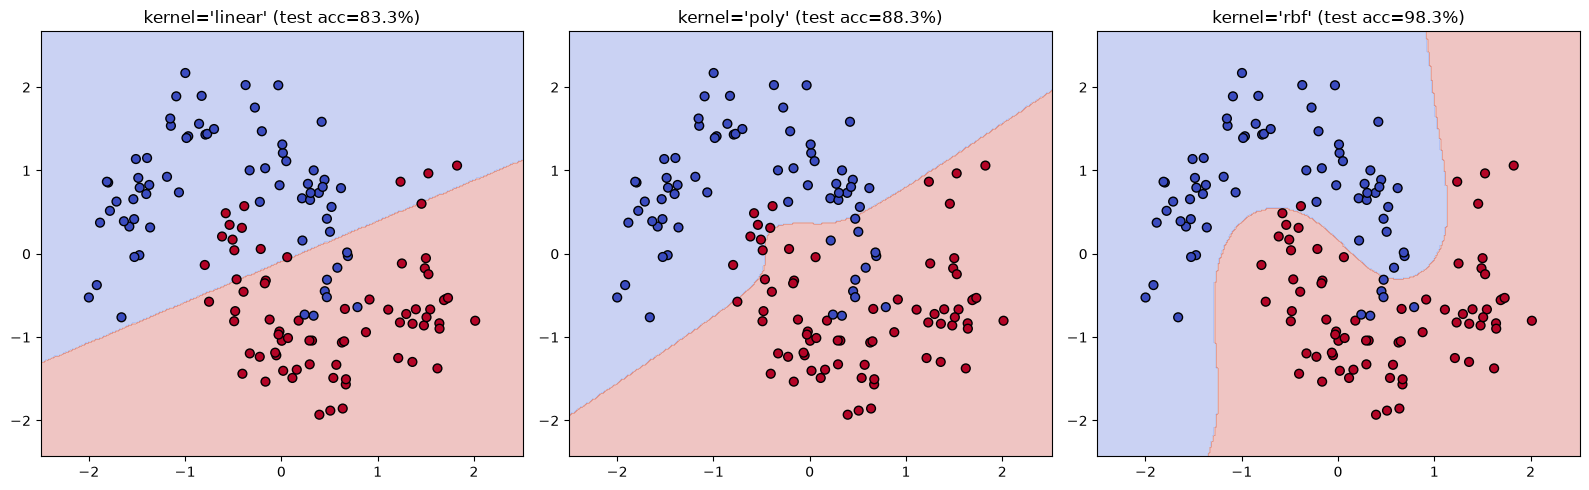

In [3]:
# Kernel comparison: linear can't separate moons, rbf can
kernels = ['linear', 'poly', 'rbf']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, kernel in zip(axes, kernels):
    svm = SVC(kernel=kernel, C=1.0, gamma='scale')
    svm.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, svm.predict(X_test_s))
    plot_decision_boundary(svm, X_train_s, y_train, ax, f"kernel='{kernel}' (test acc={acc*100:.1f}%)")

plt.tight_layout()
plt.show()

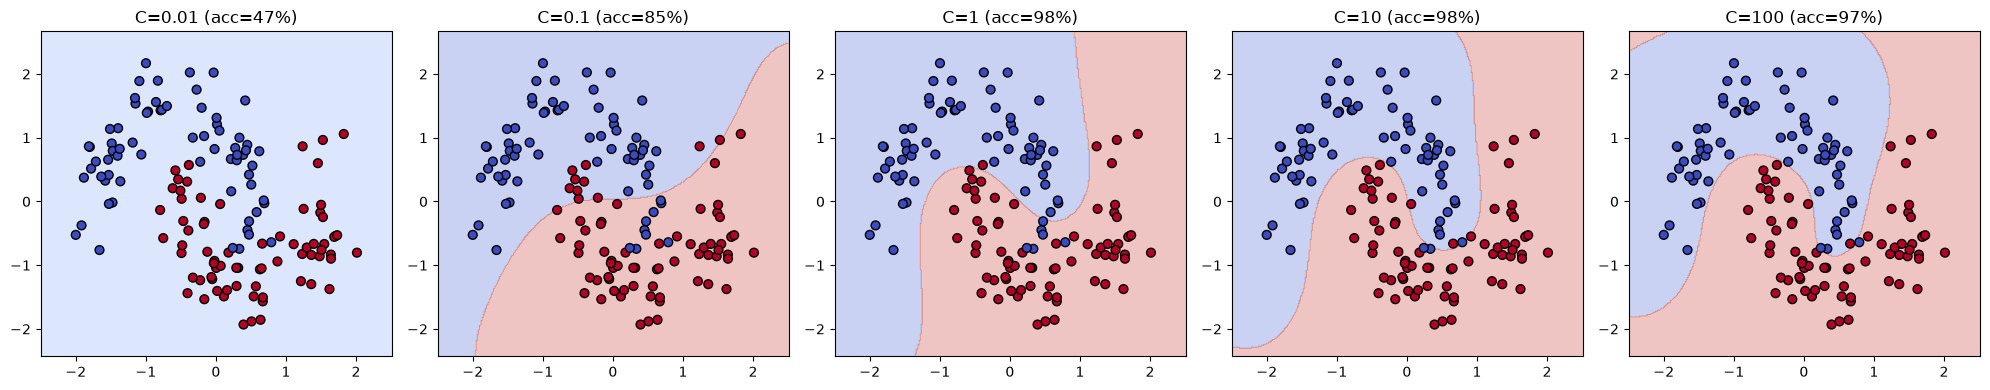

Low C -> wider margin, tolerates misclassifications (smoother boundary)
High C -> narrow margin, tries to classify every point correctly (risk of overfitting)


In [4]:
# C controls the margin/misclassification trade-off. Sweep it for the rbf kernel.
C_values = [0.01, 0.1, 1, 10, 100]
fig, axes = plt.subplots(1, len(C_values), figsize=(20, 4))

for ax, C in zip(axes, C_values):
    svm = SVC(kernel='rbf', C=C, gamma='scale')
    svm.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, svm.predict(X_test_s))
    plot_decision_boundary(svm, X_train_s, y_train, ax, f"C={C} (acc={acc*100:.0f}%)")

plt.tight_layout()
plt.show()
print("Low C -> wider margin, tolerates misclassifications (smoother boundary)")
print("High C -> narrow margin, tries to classify every point correctly (risk of overfitting)")

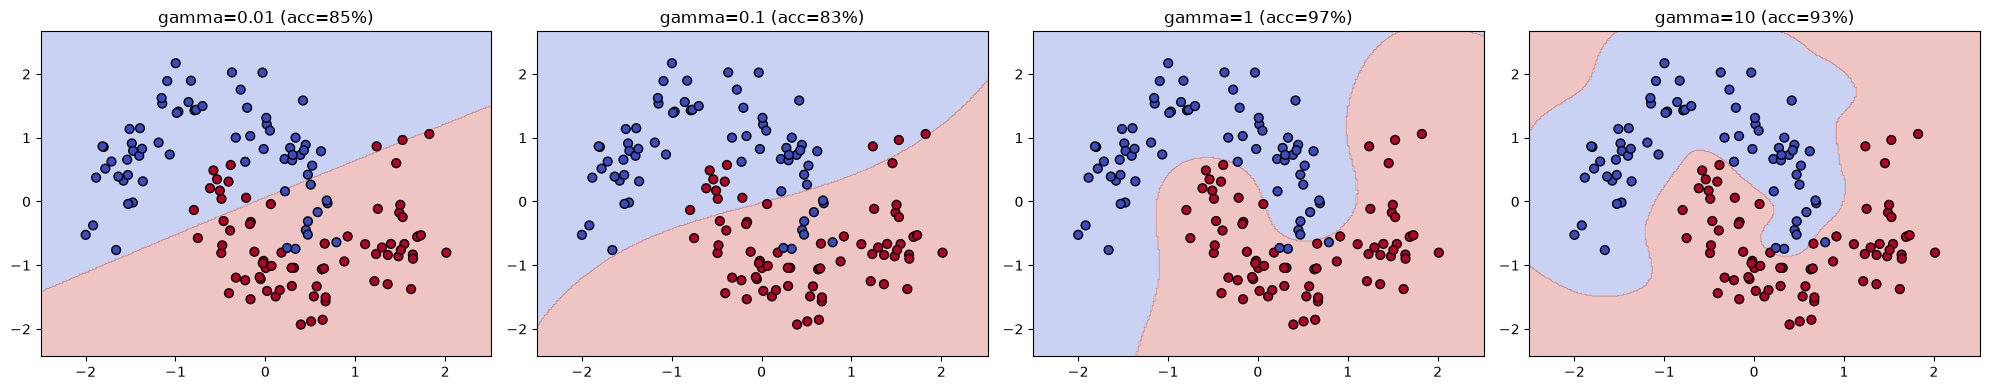

Low gamma -> smooth, far-reaching boundary (can underfit)
High gamma -> tight boundary around individual points (can overfit)


In [5]:
# gamma controls how far the influence of a single point reaches (rbf kernel)
gamma_values = [0.01, 0.1, 1, 10]
fig, axes = plt.subplots(1, len(gamma_values), figsize=(20, 4))

for ax, gamma in zip(axes, gamma_values):
    svm = SVC(kernel='rbf', C=1.0, gamma=gamma)
    svm.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, svm.predict(X_test_s))
    plot_decision_boundary(svm, X_train_s, y_train, ax, f"gamma={gamma} (acc={acc*100:.0f}%)")

plt.tight_layout()
plt.show()
print("Low gamma -> smooth, far-reaching boundary (can underfit)")
print("High gamma -> tight boundary around individual points (can overfit)")

In [6]:
# Real multi-class pipeline: wine dataset with tuned SVM
wine = load_wine()
Xw, yw = wine.data, wine.target
Xw_train, Xw_test, yw_train, yw_test = train_test_split(Xw, yw, test_size=0.3, random_state=42, stratify=yw)

scaler_w = StandardScaler()
Xw_train_s = scaler_w.fit_transform(Xw_train)
Xw_test_s = scaler_w.transform(Xw_test)

param_grid = {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.01, 0.1, 1], 'kernel': ['rbf']}
grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(Xw_train_s, yw_train)

print("Best params:", grid.best_params_)
best_svm = grid.best_estimator_
y_pred = best_svm.predict(Xw_test_s)
print(f"Test accuracy: {accuracy_score(yw_test, y_pred)*100:.2f}%")
print(classification_report(yw_test, y_pred, target_names=wine.target_names))

Best params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Test accuracy: 98.15%
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       0.95      1.00      0.98        21
     class_2       1.00      0.93      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



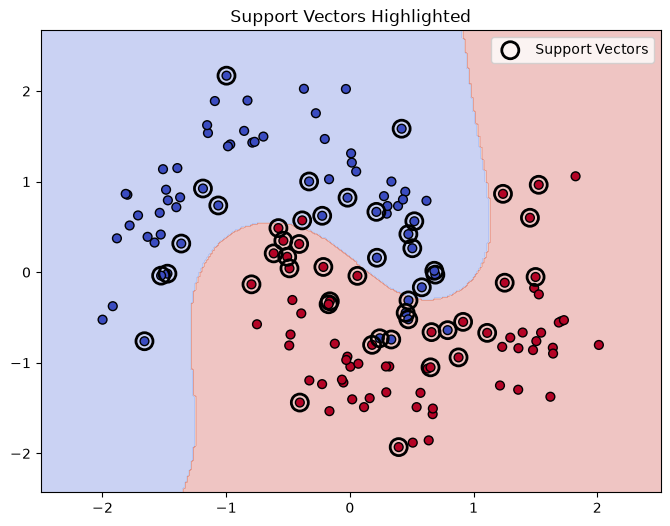

Number of support vectors: 50 out of 140 training points


In [7]:
# Support vectors are the only points that matter for the decision boundary
svm_2feat = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_2feat.fit(X_train_s, y_train)

fig, ax = plt.subplots(figsize=(8, 6))
plot_decision_boundary(svm_2feat, X_train_s, y_train, ax, 'Support Vectors Highlighted')
ax.scatter(svm_2feat.support_vectors_[:, 0], svm_2feat.support_vectors_[:, 1],
           s=150, facecolors='none', edgecolors='black', linewidths=2, label='Support Vectors')
ax.legend()
plt.show()
print(f"Number of support vectors: {len(svm_2feat.support_vectors_)} out of {len(X_train_s)} training points")